# CARGA DE LIBRERIAS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from datetime import datetime # Importar datetime para el año actual

data_input = "../data/processed/germany.veterinarians.csv"

# Ingesta de datos Externos
En esta etapa se carga el dataset limpio de la etapa anterior y se prepara la información necesaria para el modelado predictivo. El objetivo del notebook es evaluar modelos supervisados para clasificar riesgo de burnout personal a partir de variables laborales, demográficas y variables asociadas al modelo Effort-Reward Imbalance.

La variable objetivo se construye a partir de los ítems CBI_01 a CBI_06, correspondientes a la dimensión de burnout personal del Copenhagen Burnout Inventory. Estos ítems se transforman a una escala normalizada de 0 a 100, siguiendo la codificación del estudio original, donde valores más altos representan mayor nivel de agotamiento.

Posteriormente, se calcula un puntaje promedio de burnout personal y se define una variable binaria de riesgo:

*   **0 = No riesgo de burnout personal**, cuando el puntaje es menor a 50.
*   **1 = Riesgo de burnout personal**, cuando el puntaje es mayor o igual a 50.

El umbral de **50 puntos** se utiliza como criterio operativo de clasificación dentro de la escala normalizada. No se interpreta como diagnóstico clínico individual, sino como una regla de modelado para identificar casos con mayor nivel relativo de agotamiento dentro del análisis.

# Preprocesamiento de datos

El conjunto de datos germany.veterinarians.csv fue cargado y preparado para el desarrollo de modelos supervisados de clasificación. En esta etapa se realizaron las siguientes transformaciones:

*   **Carga del Dataset**: Se cargó el archivo germany.veterinarians.csv.
*   **Estandarización de Nombres de Columnas**: Se reemplazaron los espacios en los nombres de las columnas por guiones bajos para facilitar su manejo.
*   **Transformación de Ítems CBI**: Los ítems del Copenhagen Burnout Inventory correspondientes a burnout personal (CBI_01 a CBI_06) fueron transformados a una escala normalizada de 0 a 100. Se validó que estos ítems contengan solo valores permitidos (0, 25, 50, 75, 100).
*   **Cálculo del CBI_SCORE**: Se calculó un CBI_SCORE como el promedio de los ítems CBI válidos para cada persona, requiriendo un mínimo de 3 de 6 ítems válidos para que el cálculo sea realizado.
*   **Conversión de Variables ERI**: Las columnas asociadas al modelo Effort-Reward Imbalance (ERI_1 a ERI_10) fueron convertidas explícitamente a formato numérico.
*   **Verificación de Registros**: Se imprimió el número total de registros al inicio y al final del procesamiento en esta celda para verificar si hubo exclusiones.
*   **Conteo de Burnout_Score**: Se realizó un conteo de los valores únicos en la columna Burnout_Score, etiquetando los 0 como 'Sin Riesgo' y los 1 como 'Con Riesgo' para entender la distribución de la variable objetivo.

In [3]:
#from datetime import datetime # Importar datetime para el año actual

# 1) CARGAR DATASET
df = pd.read_csv(data_input)
Registros_Iniciales = len(df)

print(f"Total de registros inicial: {Registros_Iniciales}")
df.columns = df.columns.str.replace(' ', '_')

# Ítems de burnout personal del CBI
variables_cbi = [
"CBI_01", "CBI_02", "CBI_03",
    "CBI_04", "CBI_05", "CBI_06"
]

# Transformar cada ítem a escala CBI 0-100
df_cbi_transformado = df[variables_cbi]

# Validar que solo queden valores permitidos
valores_validos_cbi = [0, 25, 50, 75, 100]

df_cbi_transformado = df_cbi_transformado.where(
    df_cbi_transformado.isin(valores_validos_cbi),
    np.nan
)

# Contar cuántos ítems CBI válidos tiene cada persona
df["cbi_items_validos"] = df_cbi_transformado.notna().sum(axis=1)

# Calcular el score CBI personal solo si hay al menos 3 ítems válidos
df["CBI_SCORE"] = np.where(
    df["cbi_items_validos"] >= 3,
    df_cbi_transformado.mean(axis=1),
    np.nan
)

# Convertir explícitamente las columnas ERI a numéricas antes de sumar
eri_cols_effort = ['ERI_1', 'ERI_2', 'ERI_3']
eri_cols_reward = ['ERI_4', 'ERI_5', 'ERI_6', 'ERI_7', 'ERI_8', 'ERI_9', 'ERI_10']
df[eri_cols_effort] = df[eri_cols_effort].apply(pd.to_numeric, errors='coerce')
df[eri_cols_reward] = df[eri_cols_reward].apply(pd.to_numeric, errors='coerce')

print(df.columns) # Mostrar columnas después de las transformaciones

#revisión
revision_cbi = pd.concat(
    [
        df[variables_cbi],
        df_cbi_transformado.add_suffix("_score"),
        df[["cbi_items_validos", "CBI_SCORE"]]
    ],
    axis=1
)

revision_cbi.head()
Registros_Finales = len(df)
print(f"Total de registros luego de tratamiento: {Registros_Finales}")
print(f"Total de registros excluidos: {Registros_Iniciales - Registros_Finales}")

# Conteo de ceros y unos en 'Burnout_Score'
if 'Burnout_Score' in df.columns:
    burnout_counts = df['Burnout_Score'].value_counts().sort_index()
    print("\nConteo de 'Burnout_Score':")
    for value, count in burnout_counts.items():
        if value == 0:
            label = "Sin Riesgo"
        elif value == 1:
            label = "Con Riesgo"
        else:
            label = f"Otro ({value})"
        print(f"  {label}: {count} registros")
else:
    print("\nLa columna 'Burnout_Score' no existe en el DataFrame.")

Total de registros inicial: 3053
Index(['ERI_1', 'ERI_2', 'ERI_3', 'ERI_4', 'ERI_5', 'ERI_6', 'ERI_7', 'ERI_8',
       'ERI_9', 'ERI_10', 'CBI_01', 'CBI_02', 'CBI_03', 'CBI_04', 'CBI_05',
       'CBI_06', 'gender', 'birth_year', 'status_of_employment',
       'field_of_work', 'federal_state', 'community_size', 'income',
       'working_hours', 'age', 'CBI_SCORE', 'Burnout_Score',
       'cbi_items_validos'],
      dtype='str')
Total de registros luego de tratamiento: 3053
Total de registros excluidos: 0

Conteo de 'Burnout_Score':
  Sin Riesgo: 1423 registros
  Con Riesgo: 1630 registros


#Transformación de variables

In [ ]:
display(df)

,ERI_1,ERI_2,ERI_3,ERI_4,ERI_5,ERI_6,ERI_7,ERI_8,ERI_9,ERI_10,...,status_of_employment,field_of_work,federal_state,community_size,income,working_hours,CBI_SCORE,Burnout_Score,age,cbi_items_validos
0,3,3,3,1,3,3,3,2,2,1,...,9,12,2,2,1,60,33.333333,0,40,6
1,2,2,2,3,3,2,1,3,3,3,...,2,9,4,2,3,35,75.000000,1,46,6
2,3,3,3,3,2,2,1,3,3,3,...,2,9,4,1,3,42,37.500000,0,37,6
3,3,4,4,1,2,2,2,2,2,3,...,2,5,4,3,3,45,41.666667,0,42,6
4,3,3,3,3,2,2,2,3,3,3,...,2,2,4,4,2,40,95.833333,1,48,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3048,2,2,2,3,2,2,1,2,4,2,...,2,2,2,2,3,35,62.500000,1,46,6
3049,3,4,4,3,2,2,2,3,3,3,...,1,1,9,3,6,40,37.500000,0,70,6
3050,3,3,2,2,4,2,2,2,2,1,...,1,1,9,1,1,35,54.166667,1,54,6
3051,3,4,3,2,3,2,4,2,3,1,...,2,1,1,3,3,55,45.833333,0,40,6


Esta celda realiza los siguientes pasos clave para la preparación del dataset antes del entrenamiento de los modelos:

1.  **Carga y Copia del DataFrame (dff = df.copy()):** Se crea una copia del DataFrame df (que ya ha sido preprocesado en celdas anteriores) para trabajar en él sin modificar el original. Se asegura que la columna working_hours sea numérica.

2.  **Creación de age_group:** Se crea una nueva característica categórica age_group a partir de la columna age. Esto categoriza a los individuos en rangos de edad (menor a 18, 18-24, 25-34, etc.), lo que puede ser útil para el modelo.

3.  **Eliminación y Aseguramiento de Registros del Target:** Se eliminan todas las filas donde el Burnout_Score es nulo y se asegura que solo contenga valores binarios (0 o 1). Esto es crucial porque el target (variable objetivo) se deriva de esta columna, y los registros sin un valor válido no pueden usarse para el entrenamiento.

4.  **Definición del Target y Features:**
    *   y_allorig: Se define la variable objetivo binaria directamente de la columna Burnout_Score.
    *   orignumeric_features: Se definen las características numéricas originales que se usarán como predictores (age, working_hours).
    *   origcategorical_features: Se definen las características categóricas originales que se usarán, incluyendo ítems ERI y variables demográficas (age_group, gender, etc.).
    *   origcategorical_features_with_cbi: Se extiende la lista de características categóricas incluyendo los ítems CBI_01 a CBI_06.
    *   X_allorig_cbi: Se crea el DataFrame X con todas las características predictoras seleccionadas.

5.  **Asegurar Tipos de Datos:** Se asegura que las columnas categóricas tengan el tipo object y las numéricas el tipo numeric para que los ColumnTransformer los manejen correctamente.

6.  **Procesamiento de Pipelines (numeric_transformer, `categorical_transformer, preprocess_with_cbi):**
    *   numeric_transformer: Un pipeline para características numéricas que aplica SimpleImputer(strategy='median') para manejar valores faltantes imputando la mediana.
    *   categorical_transformer: Un pipeline para características categóricas que aplica SimpleImputer(strategy='most_frequent') para imputar la moda y OneHotEncoder(handle_unknown='ignore') para convertir variables categóricas en un formato numérico que los modelos puedan entender.
    *   preprocess_with_cbi: Un ColumnTransformer que combina los transformadores numéricos y categóricos, aplicándolos a las columnas correspondientes del conjunto X_allorig_cbi.

7.  **División de Datos (split_data):** Se define una función split_data para dividir el conjunto de datos en tres partes:
    *   **Entrenamiento (60%):** Para entrenar el modelo.
    *   **Validación (20%):** Para la optimización de hiperparámetros y umbrales.
    *   **Prueba (20%):** Para la evaluación final del rendimiento del modelo en datos no vistos.
    La división se realiza con stratify=y para asegurar que la proporción de las clases de la variable objetivo se mantenga en cada subconjunto.

8.  **Optimización del Umbral (get_best_t):** Se define una función get_best_t que calcula el umbral de clasificación óptimo (threshold) en el conjunto de validación (X_val, y_val). Este umbral maximiza la balanced_accuracy_score, lo cual es importante para conjuntos de datos con clases desbalanceadas.

In [24]:
# 1) CARGAR DATASET
dff = df.copy()
dff['working_hours'] = pd.to_numeric(dff['working_hours'], errors='coerce')

# NUEVO: Crear columna 'age_group'
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
dff['age_group'] = pd.cut(dff['age'], bins=bins, labels=labels, right=False)

variables_cbi_preds = ['CBI_01', 'CBI_02', 'CBI_03', 'CBI_04', 'CBI_05', 'CBI_06']

# 2) ELIMINAR REGISTROS SIN TARGET y asegurar que Burnout_Score sea binario (0 o 1)
dff = dff[dff["Burnout_Score"].notna()].copy()
dff = dff[dff["Burnout_Score"].isin([0, 1])].copy() # Ensure Burnout_Score is binary (0 or 1)

# 3) DEFINIR TARGET Y FEATURES
#y_allorig = (dff['CBI_SCORE'] >= 50).astype(int) # Confirmed threshold is 75

y_allorig = (dff['Burnout_Score']).astype(int)


# Variables numericas predictoras
orignumeric_features = ['age', 'working_hours']

# Variables Categoricas predictoras
origcategorical_features = ['age_group','gender','status_of_employment','field_of_work','community_size','income'] + [f'ERI_{i}' for i in range(1, 11)]
origcategorical_features_with_cbi = origcategorical_features + variables_cbi_preds

# Conjunto de Variables predictoras
X_allorig_cbi = dff[origcategorical_features_with_cbi + orignumeric_features].copy()

# Asegurar tipos
for df_tmp, feat_list in [(X_allorig_cbi, origcategorical_features_with_cbi)]:
    for col in feat_list: df_tmp[col] = df_tmp[col].astype(object)
    for col in orignumeric_features: df_tmp[col] = pd.to_numeric(df_tmp[col], errors='coerce')

# 4) PROCESAMIENTO DE PIPELINE
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocess_with_cbi = ColumnTransformer(transformers=[('num', numeric_transformer, orignumeric_features), ('cat', categorical_transformer, origcategorical_features_with_cbi)])

# 5) DIVIDIR DATASETS
def split_data(X, y):
    Xt_v, Xt, yt_v, yt = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    Xtr, Xv, ytr, yv = train_test_split(Xt_v, yt_v, test_size=0.25, random_state=42, stratify=yt_v)
    return Xtr, Xv, Xt, ytr, yv, yt

X_trainCBI, X_valCBI, X_testCBI, y_trainCBI, y_valCBI, y_testCBI = split_data(X_allorig_cbi, y_allorig)

# 6) OPTIMIZAR UMBRAL Y EVALUAR
def get_best_t(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    best_t, best_score = 0.5, 0
    for t in np.linspace(0.01, 0.99, 100):
        preds = (probs >= t).astype(int)
        score = balanced_accuracy_score(y, preds)
        #score = f1_score(y, preds, pos_label=1)
        if score > best_score: best_score, best_t = score, t
    return best_t

# ENTRENAMIENTO Y EVALUACION DE RANDOM FOREST

Esta celda se encarga de la parte de entrenamiento y evaluación del modelo de **Random Forest**, específicamente con el conjunto de características ERI, CBI y Demográficas.

1.  **Definición de la Grilla de Parámetros (param_grid):** Se establece un diccionario con los diferentes valores de hiperparámetros que GridSearchCV probará para optimizar el modelo de Random Forest. Esto incluye:
    *   "model__n_estimators": Número de árboles en el bosque.
    *   "model__max_depth": Profundidad máxima de cada árbol.
    *   "model__min_samples_split": Número mínimo de muestras requeridas para dividir un nodo interno.
    *   "model__min_samples_leaf": Número mínimo de muestras requeridas en una hoja.
    *   "model__max_features": Número de características a considerar en cada división.
    *   "model__class_weight": Se usa el valor "balanced" para manejar el posible desbalance de clases en la variable objetivo.

2.  **Estrategia de Validación Cruzada (cv_strategy):** Se define StratifiedKFold con "n_splits=3" para la validación cruzada. Esto asegura que la proporción de las clases de la variable objetivo se mantenga constante en cada fold, lo cual es importante cuando hay desbalance de clases.

3.  **Configuración del Pipeline para Random Forest (pipeline_cbi):**
    *   Se crea un Pipeline que primero aplica el preprocesamiento ("preprocess_with_cbi", que incluye imputación y OneHotEncoder) y luego el modelo "RandomForestClassifier".
    *   El modelo se inicializa con "class_weight='balanced'" y "random_state=42" para reproducibilidad, y "n_jobs=-1" para usar todos los núcleos del procesador disponible y acelerar el entrenamiento.

4.  **Búsqueda de Hiperparámetros con GridSearchCV (grid_search_cbi):**
    *   Se utiliza GridSearchCV para encontrar la mejor combinación de hiperparámetros dentro de "param_grid" para el "pipeline_cbi".
    *   La métrica de evaluación utilizada es "scoring='balanced_accuracy'", lo cual es adecuado para clases desbalanceadas.
    *   Se entrena con "X_trainCBI" y "y_trainCBI" (el conjunto de entrenamiento con las características ERI, CBI y Demográficas).
    *   Una vez finalizado, se imprime la mejor combinación de parámetros y el mejor Balanced Accuracy encontrado.

5.  **Obtención del Mejor Estimador (classifier_binarioorig_CBI):** Se guarda el modelo de Random Forest con los hiperparámetros óptimos encontrados por GridSearchCV.

6.  **Optimización del Umbral (t_cbi = get_best_t(...)):** Se llama a la función "get_best_t" (definida en la celda anterior) para encontrar el umbral de clasificación óptimo ("t_cbi") en el conjunto de validación ("X_valCBI", "y_valCBI") que maximiza el Balanced Accuracy.

7.  **Evaluación Final (final_eval):** Se define y se utiliza la función "final_eval" para evaluar el modelo con el umbral óptimo en el conjunto de prueba ("X_testCBI", "y_testCBI"). Esta función:
    *   Realiza predicciones binarias usando el umbral óptimo.
    *   Imprime el Balanced Accuracy y un "classification_report" (que incluye precisión, recall y f1-score por clase).
    *   Muestra una "confusion_matrix" visualizada con "seaborn.heatmap", para una comprensión clara del rendimiento del modelo en cada clase, utilizando "Sin Riesgo" y "Con Riesgo" como etiquetas.

En resumen, esta celda entrena y optimiza el modelo de Random Forest con las características más completas (ERI + CBI + Demográficas), encuentra el mejor umbral de clasificación y evalúa su rendimiento en un conjunto de datos no visto.

Iniciando GridSearchCV para el modelo RF (ERI + DEMOGRAFICAS)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Mejores parámetros para RF (ERI + CBI + DEMOGRAFICAS): {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Mejor balanced accuracy para RF (ERI + CBI + DEMOGRAFICAS): 0.9855976403031255

=== RF (ERI + CBI + DEMOGRAFICAS) ===
Balanced accuracy: 0.9796092993219245
              precision    recall  f1-score   support

  Sin Riesgo       0.99      0.97      0.98       285
  Con Riesgo       0.97      0.99      0.98       326

    accuracy                           0.98       611
   macro avg       0.98      0.98      0.98       611
weighted avg       0.98      0.98      0.98       611



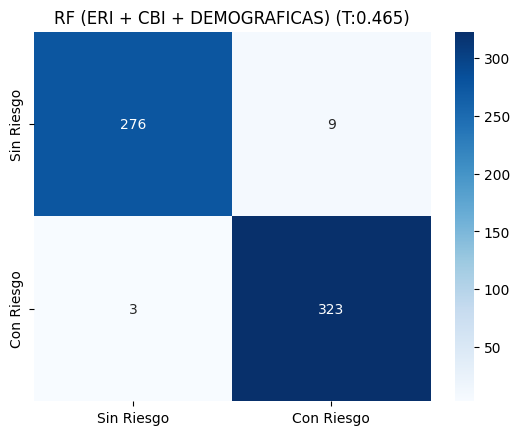

In [25]:
# 6) ENTRENAMIENTO CON BÚSQUEDA DE HIPERPARÁMETROS (GridSearchCV)

# Grilla de parámetros a probar
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [5, 7, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": ["balanced"]
}
# Usar StratifiedKFold para mantener la proporción de clases durante la validación cruzada
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Iniciando GridSearchCV para el modelo RF (ERI + DEMOGRAFICAS)...")

# Modelo: RF (ERI + CBI + DEMO)
pipeline_cbi = Pipeline(steps=[
    ('preprocess', preprocess_with_cbi),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])
grid_search_cbi = GridSearchCV(
    estimator=pipeline_cbi,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv_strategy,
    verbose=2,
    n_jobs=-1
)
grid_search_cbi.fit(X_trainCBI, y_trainCBI)
classifier_binarioorig_CBI = grid_search_cbi.best_estimator_
print("Mejores parámetros para RF (ERI + CBI + DEMOGRAFICAS):", grid_search_cbi.best_params_)
print("Mejor balanced accuracy para RF (ERI + CBI + DEMOGRAFICAS):", grid_search_cbi.best_score_)

# 7) OPTIMIZAR UMBRAL Y EVALUAR

t_cbi = get_best_t(classifier_binarioorig_CBI, X_valCBI, y_valCBI)

def final_eval(model, X, y, t, title):
    pred = (model.predict_proba(X)[:, 1] >= t).astype(int)
    print(f'\n=== {title} ===')
    print('Balanced accuracy:', balanced_accuracy_score(y, pred))
    print(classification_report(y, pred, target_names=['Sin Riesgo', 'Con Riesgo']))
    sns.heatmap(confusion_matrix(y, pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Sin Riesgo', 'Con Riesgo'], yticklabels=['Sin Riesgo', 'Con Riesgo'])
    plt.title(f'{title} (T:{t:.3f})')
    plt.show()

final_eval(classifier_binarioorig_CBI, X_testCBI, y_testCBI, t_cbi, 'RF (ERI + CBI + DEMOGRAFICAS)')

# ENTRENAMIENTO Y EVALUACION DE REGRESIÓN LOGÍSTICA

Esta celda se enfoca en el entrenamiento y evaluación del modelo de **Regresión Logística**, utilizando el mismo conjunto completo de características: ERI, CBI y Demográficas:

1.  **Transformación de Features Numéricas con Escalado (numeric_transformer_scaled y preprocess_with_cbi_scaled):**
    *   A diferencia del Random Forest, los modelos lineales como la Regresión Logística son sensibles a la escala de las características. Por lo tanto, se introduce un StandardScaler en el pipeline numérico para estandarizar los datos (media 0, desviación estándar 1).
    *   preprocess_with_cbi_scaled es un ColumnTransformer que aplica esta transformación escalada a las características numéricas y el OneHotEncoder a las categóricas.

2.  **Definición de la Grilla de Parámetros para Regresión Logística (param_grid_lr):** Se especifican los hiperparámetros que GridSearchCV probará para la Regresión Logística:
    *   model__C: Es el inverso de la fuerza de regularización. Valores más pequeños indican una regularización más fuerte. Se prueban diferentes valores para encontrar el equilibrio óptimo entre ajuste y generalización.
    *   model__penalty: Se usa "l2" (regularización Ridge) para evitar el sobreajuste.
    *   model__solver: Se elige "liblinear" porque es eficiente para datasets pequeños y medianos, y soporta penalización l1 y l2.

3.  **Estrategia de Validación Cruzada (cv_strategy_lr):** Al igual que para Random Forest, se utiliza StratifiedKFold con n_splits=3 para asegurar que la distribución de clases se mantenga en cada fold durante la validación cruzada, lo que es importante para manejar el desbalance de clases.

4.  **Configuración del Pipeline para Regresión Logística (pipeline_lr_cbi):**
    *   Se crea un Pipeline que primero aplica el preprocesamiento escalado (preprocess_with_cbi_scaled) y luego el modelo LogisticRegression.
    *   El modelo se inicializa con class_weight="balanced" para abordar el desbalance de clases y random_state=42 para reproducibilidad.

5.  **Búsqueda de Hiperparámetros con GridSearchCV (grid_search_lr_cbi):**
    *   GridSearchCV busca la mejor combinación de parámetros en param_grid_lr para el pipeline_lr_cbi.
    *   Se entrena con X_trainCBI y y_trainCBI (el conjunto de entrenamiento).
    *   Una vez completado, se imprimen los mejores parámetros y el mejor Balanced Accuracy obtenido.

6.  **Obtención del Mejor Estimador (classifier_lr_binarioorig_CBI):** Se guarda el modelo de Regresión Logística con los hiperparámetros óptimos encontrados por GridSearchCV.

7.  **Optimización del Umbral (t_lr_cbi = get_best_t(...)):** Se utiliza la función get_best_t (definida en una celda anterior) para calcular el umbral de clasificación óptimo (t_lr_cbi) en el conjunto de validación (X_valCBI, y_valCBI) que maximiza el Balanced Accuracy.

8.  **Evaluación Final (final_eval(...)):** Finalmente, se llama a la función final_eval (redefinida en esta sección) para evaluar el modelo con el umbral óptimo en el conjunto de prueba (X_testCBI, y_testCBI). Esta función imprime el Balanced Accuracy, un informe de clasificación detallado y una matriz de confusión visualizada con etiquetas "Sin Riesgo" y "Con Riesgo".

En resumen, esta celda se encarga de entrenar, optimizar y evaluar el modelo de Regresión Logística con las características ERI, CBI y Demográficas, prestando especial atención al escalado de características y la optimización del umbral para un rendimiento óptimo en un escenario con posible desbalance de clases.

Iniciando GridSearchCV para el modelo LR (ERI + DEMOGRAFICAS)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Mejores parámetros para LR (ERI + CBI + DEMO): {'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Mejor balanced accuracy para LR (ERI + CBI + DEMO): 0.9927571636542608

=== LR (ERI + CBI + DEMOGRAFICAS) ===
Balanced accuracy: 0.9964912280701754
              precision    recall  f1-score   support

  Sin Riesgo       1.00      0.99      1.00       285
  Con Riesgo       0.99      1.00      1.00       326

    accuracy                           1.00       611
   macro avg       1.00      1.00      1.00       611
weighted avg       1.00      1.00      1.00       611



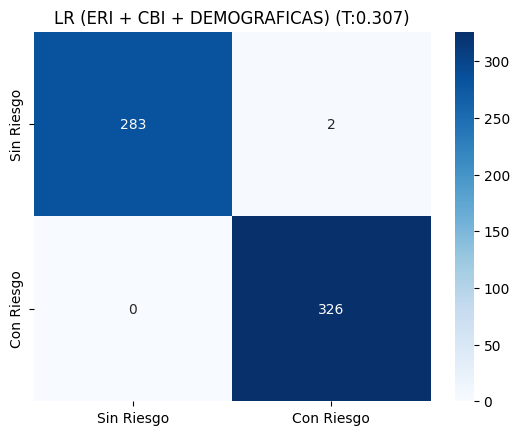

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
# 4) PROCESAMIENTO DE PIPELINE
numeric_transformer_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocess_with_cbi_scaled = ColumnTransformer(transformers=[('num', numeric_transformer_scaled, orignumeric_features), ('cat', categorical_transformer, origcategorical_features_with_cbi)])

# 6) ENTRENAMIENTO CON BÚSQUEDA DE HIPERPARÁMETROS (GridSearchCV) para Regresión Logística

# Parámetros para GridSearchCV para Logistic Regression
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10, 100],  # Fuerza de regularización inversa
    'model__penalty': ['l2'],          # Tipo de regularización (l1/l2)
    'model__solver': ['liblinear']     # Solver que soporta l1 y l2
}

# Usar StratifiedKFold para mantener la proporción de clases durante la validación cruzada
cv_strategy_lr = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Iniciando GridSearchCV para el modelo LR (ERI + DEMOGRAFICAS)...")
# Modelo  LR: RF (ERI + CBI + DEMO)
pipeline_lr_cbi = Pipeline(steps=[
    ('preprocess', preprocess_with_cbi_scaled),
    ('model', LogisticRegression(class_weight='balanced', random_state=42))
])
grid_search_lr_cbi = GridSearchCV(
    estimator=pipeline_lr_cbi,
    param_grid=param_grid_lr,
    scoring='balanced_accuracy',
    cv=cv_strategy_lr,
    verbose=2,
    n_jobs=-1
)
grid_search_lr_cbi.fit(X_trainCBI, y_trainCBI)
classifier_lr_binarioorig_CBI = grid_search_lr_cbi.best_estimator_
print("Mejores parámetros para LR (ERI + CBI + DEMO):", grid_search_lr_cbi.best_params_)
print("Mejor balanced accuracy para LR (ERI + CBI + DEMO):", grid_search_lr_cbi.best_score_)

# 7) OPTIMIZAR UMBRAL Y EVALUAR para modelos de Regresión Logística

def final_eval(model, X, y, t, title):
    pred = (model.predict_proba(X)[:, 1] >= t).astype(int)
    print(f'\n=== {title} ===')
    print('Balanced accuracy:', balanced_accuracy_score(y, pred))
    print(classification_report(y, pred, target_names=['Sin Riesgo', 'Con Riesgo']))
    sns.heatmap(confusion_matrix(y, pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Sin Riesgo', 'Con Riesgo'], yticklabels=['Sin Riesgo', 'Con Riesgo'])
    plt.title(f'{title} (T:{t:.3f})')
    plt.show()


t_lr_cbi = get_best_t(classifier_lr_binarioorig_CBI, X_valCBI, y_valCBI)
final_eval(classifier_lr_binarioorig_CBI, X_testCBI, y_testCBI, t_lr_cbi, 'LR (ERI + CBI + DEMOGRAFICAS)')

# ENTRENAMIENTO Y EVALUACION DE SUPPORT VECTOR MACHINE (SVM)

Esta celda se encarga del entrenamiento y la evaluación del modelo de **Máquinas de Vectores de Soporte (SVM)**, utilizando el conjunto completo de características: ERI, CBI y Demográficas:

1.  **Transformación de Features Numéricas con Escalado (numeric_transformer_scaled y preprocess_with_cbi_scaled):**
    *   Al igual que la Regresión Logística, los modelos SVM son sensibles a la escala de las características. Por ello, se utiliza **StandardScaler** en el pipeline numérico para estandarizar los datos (media 0, desviación estándar 1).
    *   **preprocess_with_cbi_scaled** es un ColumnTransformer que aplica esta transformación escalada a las características numéricas y el OneHotEncoder a las categóricas.

2.  **Definición de la Grilla de Parámetros para SVM (param_grid_svc):** Se especifican los hiperparámetros que GridSearchCV probará para el modelo SVM:
    *   **model__C**: Es el parámetro de regularización. Un C pequeño implica una regularización fuerte, mientras que un C grande indica una regularización más débil. Se prueban diferentes valores para encontrar el equilibrio óptimo entre ajuste y generalización.
    *   **model__kernel**: Define el tipo de kernel a usar en el algoritmo. Se prueban 'linear' (para un límite de decisión lineal) y 'rbf' (Radial Basis Function, para límites de decisión no lineales).

3.  **Estrategia de Validación Cruzada (cv_strategy_svc):** Similar a los otros modelos, se utiliza **StratifiedKFold** con **n_splits=3** para asegurar que la proporción de las clases de la variable objetivo se mantenga constante en cada fold durante la validación cruzada. Esto es crucial cuando hay desbalance de clases.

4.  **Configuración del Pipeline para SVM (pipeline_svc_cbi):**
    *   Se crea un **Pipeline** que primero aplica el preprocesamiento escalado (preprocess_with_cbi_scaled) y luego el modelo **SVC** (Support Vector Classifier).
    *   El modelo se inicializa con **class_weight="balanced"** para manejar el desbalance de clases, **random_state=42** para reproducibilidad, y **probability=True** para permitir el cálculo de probabilidades de clase, necesario para la optimización del umbral.

5.  **Búsqueda de Hiperparámetros con GridSearchCV (grid_search_svc_cbi):**
    *   **GridSearchCV** busca la mejor combinación de parámetros en param_grid_svc para el pipeline_svc_cbi.
    *   Se entrena con **X_trainCBI** y **y_trainCBI** (el conjunto de entrenamiento).
    *   Una vez completado, se imprimen los mejores parámetros y el mejor Balanced Accuracy obtenido.

6.  **Obtención del Mejor Estimador (classifier_svc_binarioorig_CBI):** Se guarda el modelo SVM con los hiperparámetros óptimos encontrados por GridSearchCV.

7.  **Optimización del Umbral (t_svc_cbi = get_best_t(...)):** Se utiliza la función **get_best_t** (definida en una celda anterior) para calcular el umbral de clasificación óptimo (t_svc_cbi) en el conjunto de validación (**X_valCBI**, **y_valCBI**) que maximiza el Balanced Accuracy.

8.  **Evaluación Final (final_eval(...)):** Finalmente, se llama a la función **final_eval** para evaluar el modelo con el umbral óptimo en el conjunto de prueba (**X_testCBI**, **y_testCBI**). Esta función imprime el Balanced Accuracy, un informe de clasificación detallado y una matriz de confusión para visualizar el rendimiento del modelo en datos no vistos.

En resumen, esta celda entrena, optimiza y evalúa el modelo SVM con las características ERI, CBI y Demográficas, prestando especial atención al escalado de características y la optimización del umbral para lograr un rendimiento robusto en un escenario con posible desbalance de clases.

Iniciando GridSearchCV para el modelo SVM (ERI + DEMO)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Mejores parámetros para SVM (ERI + CBI + DEMOGRAFICAS): {'model__C': 10, 'model__kernel': 'linear'}
Mejor balanced accuracy para SVM (ERI + CBI + DEMOGRAFICAS): 0.9931886858047796

=== SVM (ERI + CBI + DEMOGRAFICAS) ===
Balanced accuracy: 1.0
              precision    recall  f1-score   support

  Sin Riesgo       1.00      1.00      1.00       285
  Con Riesgo       1.00      1.00      1.00       326

    accuracy                           1.00       611
   macro avg       1.00      1.00      1.00       611
weighted avg       1.00      1.00      1.00       611



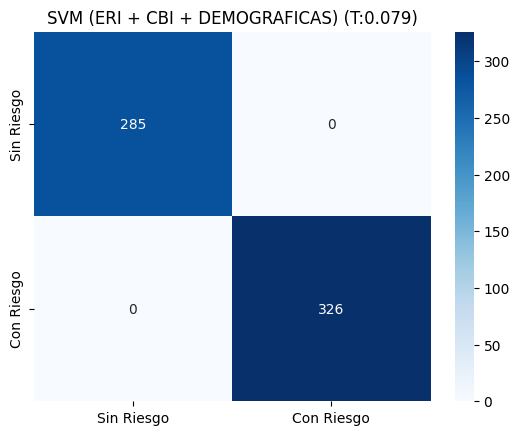

In [27]:
from sklearn.svm import SVC

# ENTRENAMIENTO CON BÚSQUEDA DE HIPERPARÁMETROS (GridSearchCV) para SVM

# Parámetros para GridSearchCV para SVM
param_grid_svc = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf']
}

# Usar StratifiedKFold para mantener la proporción de clases durante la validación cruzada
cv_strategy_svc = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Iniciando GridSearchCV para el modelo SVM (ERI + DEMO)...")

# Modelo SVM: (ERI + CBI + DEMO)
pipeline_svc_cbi = Pipeline(steps=[
    ('preprocess', preprocess_with_cbi_scaled),
    ('model', SVC(class_weight='balanced', random_state=42, probability=True))
])
grid_search_svc_cbi = GridSearchCV(
    estimator=pipeline_svc_cbi,
    param_grid=param_grid_svc,
    scoring='balanced_accuracy',
    cv=cv_strategy_svc,
    verbose=2,
    n_jobs=-1
)
grid_search_svc_cbi.fit(X_trainCBI, y_trainCBI)
classifier_svc_binarioorig_CBI = grid_search_svc_cbi.best_estimator_
print("Mejores parámetros para SVM (ERI + CBI + DEMOGRAFICAS):", grid_search_svc_cbi.best_params_)
print("Mejor balanced accuracy para SVM (ERI + CBI + DEMOGRAFICAS):", grid_search_svc_cbi.best_score_)

#  OPTIMIZAR UMBRAL Y EVALUAR para modelos SVM


t_svc_cbi = get_best_t(classifier_svc_binarioorig_CBI, X_valCBI, y_valCBI)

def final_eval(model, X, y, t, title):
    pred = (model.predict_proba(X)[:, 1] >= t).astype(int)
    print(f'\n=== {title} ===')
    print('Balanced accuracy:', balanced_accuracy_score(y, pred))
    print(classification_report(y, pred, target_names=['Sin Riesgo', 'Con Riesgo']))
    sns.heatmap(confusion_matrix(y, pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Sin Riesgo', 'Con Riesgo'], yticklabels=['Sin Riesgo', 'Con Riesgo'])
    plt.title(f'{title} (T:{t:.3f})')
    plt.show()


final_eval(classifier_svc_binarioorig_CBI, X_testCBI, y_testCBI, t_svc_cbi, 'SVM (ERI + CBI + DEMOGRAFICAS)')

# IMPORTANCIA DE LAS VARIABLES

Para entender qué características son más influyentes en las predicciones de los modelos, se ha implementado una función personalizada de importancia por permutación. Esta técnica evalúa cómo el desempeño del modelo se ve afectado cuando se alteran aleatoriamente los valores de una característica específica, permitiendo identificar cuáles son cruciales para la predicción.

La importancia por permutación se calculó a través de la función permutation_importance_pipeline y considera dos aspectos clave:

1.  Concordancia con la Evaluación Final del Modelo: A diferencia de una implementación estándar, esta función integra el umbral optimizado que se obtuvo durante la evaluación de cada modelo. Esto asegura que la importancia de las variables se mida bajo los mismos criterios con los que se evalúa el rendimiento general del modelo, proporcionando resultados más coherentes.
2.  Trabajo con Variables Originales: Al aplicar la importancia por permutación sobre el pipeline completo, se puede evaluar la relevancia de las características originales del dataset, antes de que se realicen transformaciones como el OneHotEncoder para variables categóricas o la imputación de valores, lo que facilita una interpretación más directa y significativa.

### Funcionamiento de "permutation_importance_pipeline":

Esta función realiza los siguientes pasos:

*   **Propósito**: Calcula cuánto disminuye el desempeño del modelo al desordenar una variable de entrada. Si el desempeño baja considerablemente, la variable es importante.
*   **Parámetros**: Recibe el modelo entrenado, los datos de entrada "X", la variable objetivo "y", el umbral de clasificación optimizado, un nombre para identificar el modelo y el número de repeticiones para cada permutación.
*   **Scorer Personalizado**: Internamente, define una función de puntuación ("scorer_con_threshold") que utiliza el umbral de clasificación optimizado. Esta función calcula el "balanced_accuracy_score" comparando las clases reales con las predicciones generadas a partir de las probabilidades del modelo y el umbral dado. Esto es fundamental para asegurar que la evaluación de la importancia sea consistente con la métrica de desempeño utilizada para optimizar el modelo.
*   **Cálculo de Permutación**: Utiliza la herramienta "permutation_importance" de scikit-learn. Esta herramienta:
    *   Calcula un desempeño base del modelo con los datos intactos.
    *   Para cada característica, mezcla aleatoriamente sus valores ("permuta") y vuelve a calcular el desempeño del modelo.
    *   La diferencia entre el desempeño base y el desempeño después de la permutación indica la importancia de la característica.
*   **Resultados y Visualización**: Los resultados se presentan en una tabla ("tabla_perm_limpia") que muestra la importancia media y la desviación estándar para cada variable. Una mayor importancia media indica que la variable es más crítica para el modelo. Además, se genera un gráfico de barras que visualiza las 15 variables más importantes, facilitando la interpretación.


**NOTA**:La manera simple de calcular la permutacion pudo haber sido algo como:
``` result = permutation_importance(
    estimator=classifier_binarioorig_CBI,
    X=X_testCBI,
    y=y_testCBI,
    scoring="balanced_accuracy",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)
```
 Sin embargo, se debían tomar en cuenta dos consideraciones importantes.
 La importancia por permutación se calculó de esta forma

1.   Para que fuera concordante con la evaluación final del modelo. Como el modelo no se evaluó usando el umbral estándar de 0,50, sino un threshold optimizado, era necesario aplicar ese mismo umbral también al calcular la importancia de las variables. Si se hubiera usado una forma más simple, el modelo habría sido evaluado con otro criterio y los resultados no serían totalmente comparables. Balanced accuracy normalmente usará thresold=0.5
2.  Además, al usar el pipeline completo, la importancia se obtiene sobre las variables originales del dataset y no sobre las columnas creadas por transformaciones como el one-hot encoding.

In [28]:
from sklearn.inspection import permutation_importance

def permutation_importance_pipeline(model, X, y, threshold, nombre_modelo, n_repeats=30):
    """
    Calcula la importancia de las variables mediante permutation importance.

    Esta función evalúa cuánto disminuye el desempeño del modelo cuando se altera
    una variable de entrada a la vez. Si al permutar una variable el desempeño baja
    mucho, se interpreta que esa variable tiene mayor importancia para el modelo.

    La función se aplica sobre el pipeline completo, por lo que permite trabajar
    con las variables originales de X, antes de transformaciones como one-hot encoding,
    imputación o escalado.

    Parámetros:
    - model: modelo o pipeline ya entrenado.
    - X: matriz de variables predictoras originales.
    - y: variable objetivo real.
    - threshold: umbral optimizado usado para convertir probabilidades en clases 0/1.
    - nombre_modelo: nombre del modelo, usado para identificar la salida y el gráfico.
    - n_repeats: número de veces que se permuta cada variable para estabilizar el resultado.
    """
    # Mensajes informativos para saber qué modelo se está analizando
    # y cuántas variables originales tiene el conjunto de datos.

    print(f"\nCalculando importancia por permutación para: {nombre_modelo}")
    print("Variables originales:", X.shape[1])

    # Función de evaluación personalizada.
    # permutation_importance necesita una función que indique cómo medir
    # el desempeño del modelo después de permutar cada variable.
    #
    # Esta función recibe automáticamente:
    # - estimator: el modelo o pipeline que se está evaluando.
    # - X_eval: los datos de entrada que se están evaluando.
    #           Durante el proceso, sklearn modifica X_eval permutando
    #           una variable a la vez.
    # - y_eval: los valores reales de la variable objetivo.

    def scorer_con_threshold(estimator, X_eval, y_real):
        # Se obtienen las probabilidades estimadas por el modelo.
        # predict_proba devuelve dos columnas:
        # columna 0: probabilidad de pertenecer a la clase 0
        # columna 1: probabilidad de pertenecer a la clase 1
        #
        # Como interesa identificar la clase positiva, se toma la columna 1.

        probabilidades = estimator.predict_proba(X_eval)[:, 1]

        # Se convierten las probabilidades en predicciones finales de clase.
        # En vez de usar el umbral estándar de 0.50, se utiliza el threshold
        # optimizado definido previamente en la evaluación del modelo.
        #
        # Si la probabilidad es mayor o igual al threshold, se clasifica como 1.
        # Si es menor, se clasifica como 0.

        predicciones = probabilidades >= threshold

        # Se calcula el balanced accuracy comparando las clases reales
        # contra las clases predichas.
        #
        # Esta métrica es adecuada cuando existe desbalance entre clases,
        # porque considera el desempeño tanto en la clase 0 como en la clase 1.
        return balanced_accuracy_score(y_real, predicciones)

    # Cálculo de la importancia por permutación.
    #
    # El procedimiento funciona así:
    # 1. Calcula el desempeño base del modelo con los datos originales.
    # 2. Permuta una variable de X, es decir, desordena sus valores entre filas.
    # 3. Vuelve a calcular el desempeño del modelo.
    # 4. Mide cuánto cambió el balanced accuracy.
    # 5. Repite el proceso para todas las variables.
    #
    # Si al permutar una variable el desempeño baja mucho,
    # esa variable se considera más importante.

    result = permutation_importance(
        estimator=model,                  # Modelo o pipeline entrenado
        X=X,                              # Variables predictoras originales
        y=y,                              # Variable objetivo real
        scoring=scorer_con_threshold,     # Métrica personalizada con threshold optimizado
        n_repeats=n_repeats,              # Número de repeticiones por variable
        random_state=42,                  # Semilla para reproducibilidad
        n_jobs=-1                         # Usa todos los núcleos disponibles del procesador
    )
    # Construcción de una tabla con los resultados.
    #
    # result.importances_mean contiene el cambio promedio en el desempeño
    # al permutar cada variable.
    #
    # result.importances_std contiene la desviación estándar de esa importancia,
    # calculada a partir de las repeticiones.
    tabla_perm = pd.DataFrame({
        "Variable": X.columns,
        "Importancia_media": result.importances_mean,
        "Importancia_std": result.importances_std
    })
    # Ordena las variables desde la más importante hasta la menos importante.
    #
    # Una mayor Importancia_media indica que el modelo depende más de esa variable,
    # porque al desordenarla el desempeño disminuye más.
    tabla_perm = tabla_perm.sort_values(
        by="Importancia_media",
        ascending=False
    ).reset_index(drop=True)
    # Redondea los resultados para facilitar la lectura de la tabla.
    tabla_perm_limpia = tabla_perm.round(4)
    # Muestra la tabla de importancias en pantalla.
    display(tabla_perm_limpia)
    # Crea una figura para graficar las 15 variables con mayor importancia.
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=tabla_perm_limpia.head(15),
        x="Importancia_media",
        y="Variable",
        palette="viridis",
        hue="Variable",
        legend=False
    )

    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Importancia por permutación - {nombre_modelo}")
    plt.xlabel("Cambio medio en Balanced Accuracy")
    plt.ylabel("Variable original")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

    return tabla_perm_limpia


Calculando importancia por permutación para: RANDOM FOREST
Variables originales: 24


,Variable,Importancia_media,Importancia_std
0,CBI_04,0.0530,0.0077
1,CBI_05,0.0449,0.0080
2,CBI_02,0.0390,0.0065
3,CBI_03,0.0361,0.0054
4,CBI_06,0.0255,0.0048
5,CBI_01,0.0250,0.0046
6,gender,0.0013,0.0011
7,age,0.0004,0.0009
8,ERI_1,0.0003,0.0020
9,status_of_employment,-0.0001,0.0003


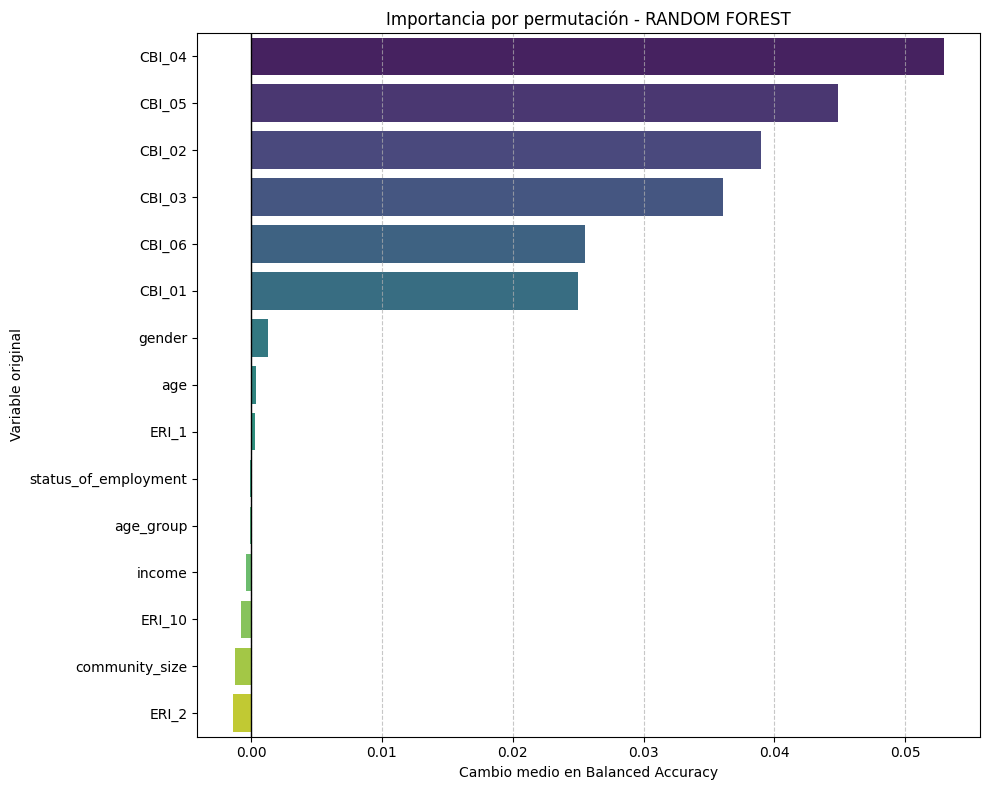


Calculando importancia por permutación para: LOGISTIC REGRESSION
Variables originales: 24


,Variable,Importancia_media,Importancia_std
0,CBI_04,0.0760,0.0069
1,CBI_03,0.0585,0.0067
2,CBI_06,0.0559,0.0062
3,CBI_02,0.0536,0.0064
4,CBI_05,0.0487,0.0068
5,CBI_01,0.0388,0.0051
6,age_group,0.0009,0.0019
7,age,0.0004,0.0017
8,gender,0.0000,0.0000
9,field_of_work,-0.0001,0.0003


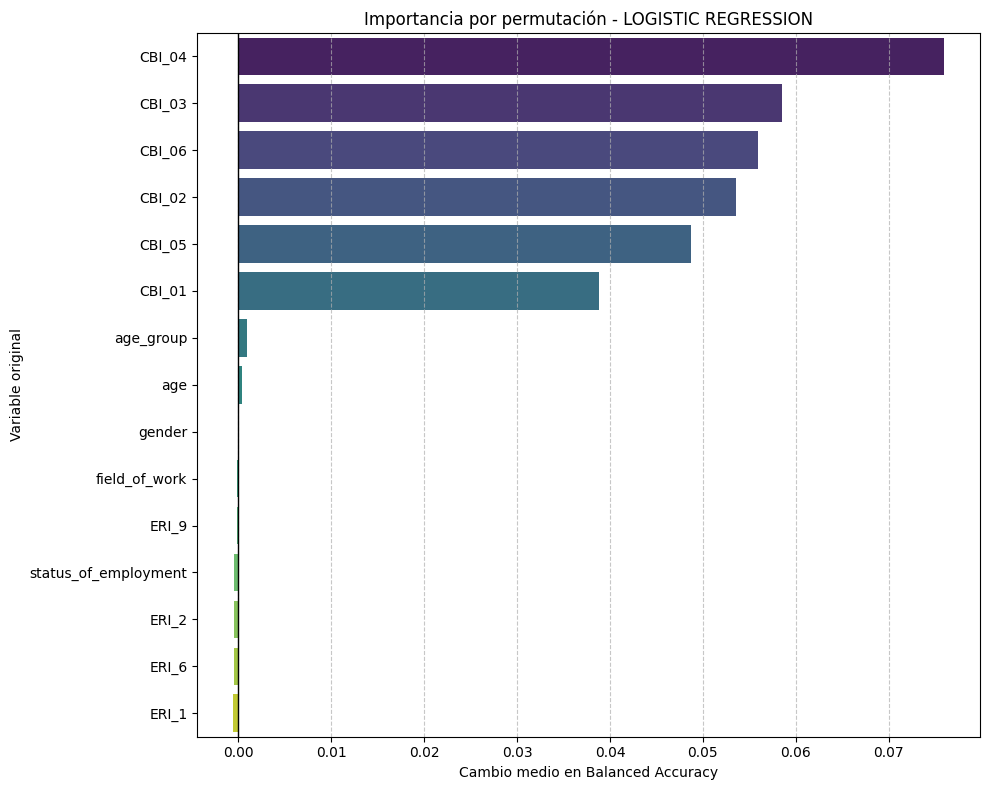


Calculando importancia por permutación para: SUPPORT VECTOR MACHINE
Variables originales: 24


,Variable,Importancia_media,Importancia_std
0,CBI_04,0.0787,0.0074
1,CBI_03,0.0617,0.0068
2,CBI_06,0.0593,0.0065
3,CBI_02,0.0583,0.0066
4,CBI_05,0.0547,0.0064
5,CBI_01,0.0416,0.0050
6,age_group,0.0000,0.0000
7,gender,0.0000,0.0000
8,ERI_2,0.0000,0.0000
9,ERI_1,0.0000,0.0000


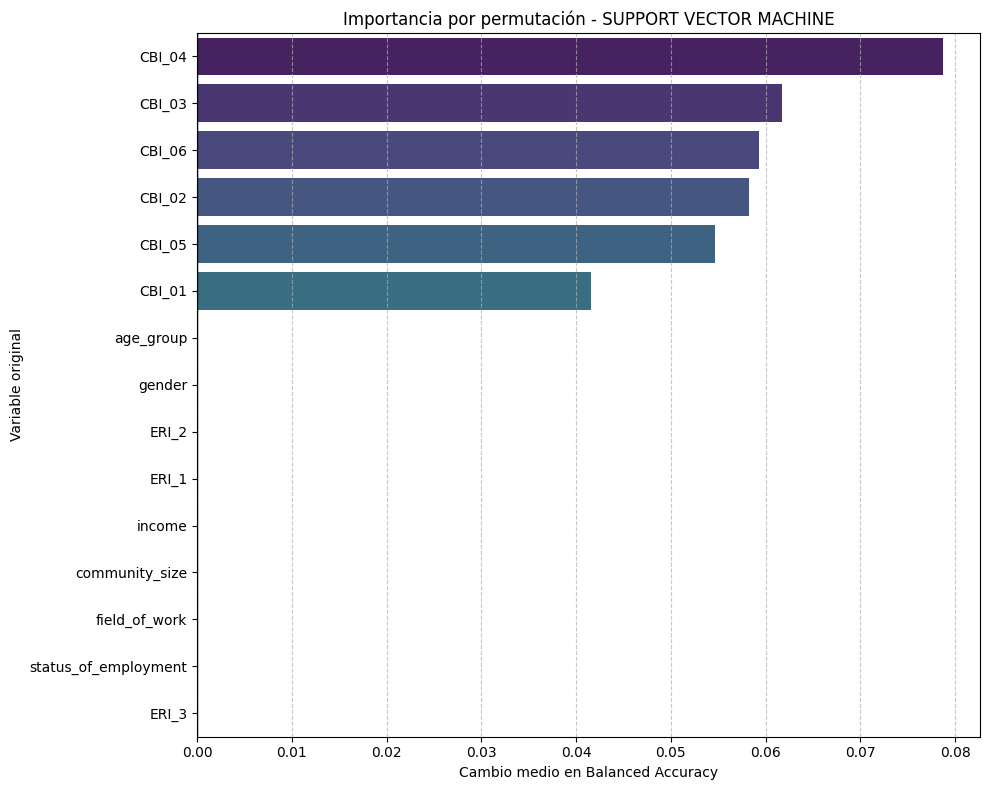


Modelos procesados:
['RF_ERI_CBI_DEMO_CONTROL', 'LR_ERI_CBI_DEMO_CONTROL', 'SVM_ERI_CBI_DEMO_CONTROL']


In [29]:

#Esto es el uso del pipeline creado en la celda de arriba
tablas_permutacion = {}

# ============================================================
# RANDOM FOREST
# ============================================================
if all(v in globals() for v in ["classifier_binarioorig_CBI", "X_testCBI", "y_testCBI", "t_cbi"]):
    tablas_permutacion["RF_ERI_CBI_DEMO_CONTROL"] = permutation_importance_pipeline(
        model=classifier_binarioorig_CBI,
        X=X_testCBI,
        y=y_testCBI,
        threshold=t_cbi,
        nombre_modelo="RANDOM FOREST"
    )


# ============================================================
# LOGISTIC REGRESSION
# ============================================================
if all(v in globals() for v in ["classifier_lr_binarioorig_CBI", "X_testCBI", "y_testCBI", "t_lr_cbi"]):
    tablas_permutacion["LR_ERI_CBI_DEMO_CONTROL"] = permutation_importance_pipeline(
        model=classifier_lr_binarioorig_CBI,
        X=X_testCBI,
        y=y_testCBI,
        threshold=t_lr_cbi,
        nombre_modelo="LOGISTIC REGRESSION"
    )


# ============================================================
# SVM
# ============================================================
if all(v in globals() for v in ["classifier_svc_binarioorig_CBI", "X_testCBI", "y_testCBI", "t_svc_cbi"]):
    tablas_permutacion["SVM_ERI_CBI_DEMO_CONTROL"] = permutation_importance_pipeline(
        model=classifier_svc_binarioorig_CBI,
        X=X_testCBI,
        y=y_testCBI,
        threshold=t_svc_cbi,
        nombre_modelo="SUPPORT VECTOR MACHINE"
    )

print("\nModelos procesados:")
print(list(tablas_permutacion.keys()))

#RESUMEN

In [30]:

def get_metrics_dict(target_name, model_name, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        'Target': target_name,
        'Modelo': model_name,
        'Acc': accuracy_score(y_true, y_pred),
        'Bal_Acc': balanced_accuracy_score(y_true, y_pred),
        'Prec_Riesgo': report.get('1', {}).get('precision', 0),
        'Rec_Riesgo': report.get('1', {}).get('recall', 0),
        'F1_Riesgo': report.get('1', {}).get('f1-score', 0),
        'Prec_No_Riesgo': report.get('0', {}).get('precision', 0),
        'Rec_No_Riesgo': report.get('0', {}).get('recall', 0)
    }

full_comparison = []
target_name = "Burnout Risk (P50)"

# Random Forest

if 'classifier_binarioorig_CBI' in globals():
    y_p_rf_cbi = (classifier_binarioorig_CBI.predict_proba(X_testCBI)[:, 1] >= t_cbi).astype(int)
    full_comparison.append(get_metrics_dict(target_name, 'RF (ERI + CBI + DEMOGRAFICAS)', y_testCBI, y_p_rf_cbi))

# Logistic Regression

if 'classifier_lr_binarioorig_CBI' in globals():
    y_p_lr_cbi = (classifier_lr_binarioorig_CBI.predict_proba(X_testCBI)[:, 1] >= t_lr_cbi).astype(int)
    full_comparison.append(get_metrics_dict(target_name, 'LR (ERI + CBI + DEMOGRAFICAS)', y_testCBI, y_p_lr_cbi))

# SVM
if 'classifier_svc_binarioorig_CBI' in globals():
    y_p_svm_cbi = (classifier_svc_binarioorig_CBI.predict_proba(X_testCBI)[:, 1] >= t_svc_cbi).astype(int)
    full_comparison.append(get_metrics_dict(target_name, 'SVM (ERI + CBI + DEMOGRAFICAS)', y_testCBI, y_p_svm_cbi))

df_full = pd.DataFrame(full_comparison)
print("=== TABLA COMPARATIVA DE MODELOS ===")
display(df_full.sort_values(by='Bal_Acc', ascending=False).style.background_gradient(subset=['Acc', 'Bal_Acc', 'Prec_Riesgo', 'Rec_Riesgo', 'F1_Riesgo', 'Prec_No_Riesgo', 'Rec_No_Riesgo'], cmap='RdYlGn'))

=== TABLA COMPARATIVA DE MODELOS ===


,Target,Modelo,Acc,Bal_Acc,Prec_Riesgo,Rec_Riesgo,F1_Riesgo,Prec_No_Riesgo,Rec_No_Riesgo
2,Burnout Risk (P50),SVM (ERI + CBI + DEMOGRAFICAS),1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,Burnout Risk (P50),LR (ERI + CBI + DEMOGRAFICAS),0.996727,0.996491,0.993902,1.000000,0.996942,1.000000,0.992982
0,Burnout Risk (P50),RF (ERI + CBI + DEMOGRAFICAS),0.980360,0.979609,0.972892,0.990798,0.981763,0.989247,0.968421


In [12]:
df_full.to_csv(
    "tabla_comparativa_modelos_burnout.csv",
    index=False,
    encoding="utf-8-sig"
)